# Face Emotion Recognition - FER-2013 (CNN)

Part 6: a CNN that classifies a 48x48 grayscale face into one of 7 emotions
(angry, disgust, fear, happy, neutral, sad, surprise).

Set `LOAD_PRETRAINED = True` to load a saved run, or `False` to train from scratch
(~1 min/epoch on GPU).

## Setup

In [1]:
import os, json, glob, time, random, shutil
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("running on", device)

Matplotlib is building the font cache; this may take a moment.


running on cpu


## Config

One switch for the whole notebook. The hyperparameters only matter when training.

In [2]:
# --- the switch that matters ---
LOAD_PRETRAINED = True      # True = load a saved run, False = train now
RUN_DIR = None              # which run to load; None = grab the latest one in ./outputs

# hyperparameters (only used when training)
EPOCHS  = 100
LR      = 1e-3
DROPOUT = 0.25

DATA_DIR, OUT_DIR = "fer", "outputs"
CLASSES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
N_CLASSES = len(CLASSES)
MEAN, STD = 0.5077, 0.2550          # grayscale stats of the FER training set

# stuff I stopped tuning a while ago
BATCH_SIZE, WIDTHS = 64, (64, 128, 256, 512)
FC_DROPOUT, WEIGHT_DECAY, VAL_FRAC = 0.5, 1e-4, 0.1
LR_PATIENCE, EARLY_STOP = 4, 12

## The data

FER-2013 ships as per-emotion jpg folders, pre-split into train/test. I load train twice
(augmented + clean) and carve out a stratified 10% for validation, so the tiny `disgust`
class survives.

In [3]:
norm = transforms.Normalize([MEAN], [STD])
eval_tf = transforms.Compose([transforms.Grayscale(), transforms.ToTensor(), norm])
# faces are roughly centred, so just flips + a little jitter. more than this hurts.
train_tf = transforms.Compose([
    transforms.Grayscale(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(), norm,
    transforms.RandomErasing(p=0.25),
])

train_aug   = datasets.ImageFolder(f"{DATA_DIR}/train", train_tf)
train_clean = datasets.ImageFolder(f"{DATA_DIR}/train", eval_tf)
test_set    = datasets.ImageFolder(f"{DATA_DIR}/test",  eval_tf)
assert train_aug.classes == CLASSES

# stratified train/val split
rng = np.random.default_rng(42)
targets = np.array(train_aug.targets)
train_idx, val_idx = [], []
for c in range(N_CLASSES):
    idx = np.where(targets == c)[0]
    rng.shuffle(idx)
    cut = round(len(idx) * VAL_FRAC)
    val_idx   += idx[:cut].tolist()
    train_idx += idx[cut:].tolist()
rng.shuffle(train_idx)

train_set = Subset(train_aug,   train_idx)
val_set   = Subset(train_clean, val_idx)

def loader(ds, shuffle=False, drop=False):
    return DataLoader(ds, BATCH_SIZE, shuffle=shuffle, drop_last=drop,
                      num_workers=0, pin_memory=(device == "cuda"))

train_loader = loader(train_set, shuffle=True, drop=True)
val_loader   = loader(val_set)
test_loader  = loader(test_set)
print(f"train {len(train_set)} | val {len(val_set)} | test {len(test_set)}")

train 25837 | val 2872 | test 7178


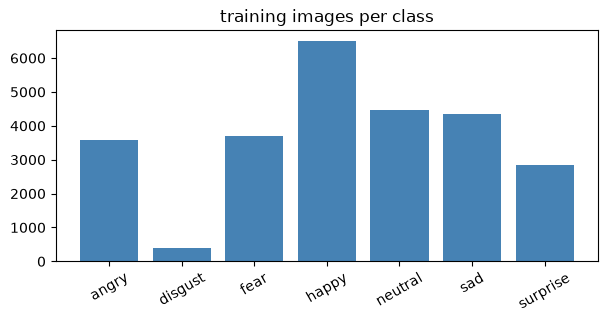

{'angry': 3595,
 'disgust': 392,
 'fear': 3687,
 'happy': 6493,
 'neutral': 4469,
 'sad': 4347,
 'surprise': 2854}

In [4]:
# how (im)balanced is it?
counts = np.bincount(targets[train_idx], minlength=N_CLASSES)
plt.figure(figsize=(7, 3))
plt.bar(CLASSES, counts, color="steelblue")
plt.title("training images per class")
plt.xticks(rotation=30)
plt.show()
dict(zip(CLASSES, counts.tolist()))   # disgust ~400 vs happy ~6500 -> class weights later

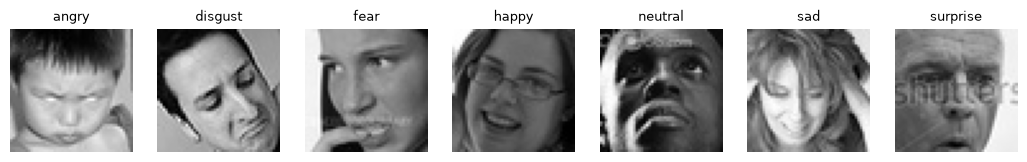

In [5]:
# one example per class, just to see what we're working with
fig, axes = plt.subplots(1, N_CLASSES, figsize=(13, 2))
for ax, c in zip(axes, range(N_CLASSES)):
    img, _ = train_clean[np.where(targets == c)[0][0]]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(CLASSES[c], fontsize=9)
    ax.axis("off")
plt.show()

## Model

VGG-style: four conv blocks (two 3x3 convs + BatchNorm/ReLU, then maxpool + dropout),
64 -> 128 -> 256 -> 512 channels. The 48x48 input halves down to 3x3, then global average
pooling feeds a small dense head. GAP keeps the classifier small.

In [6]:
def conv_block(cin, cout, p):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True),
        nn.MaxPool2d(2), nn.Dropout(p),
    )


class EmotionCNN(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        ch = [1, *WIDTHS]
        self.features = nn.Sequential(
            *[conv_block(ch[i], ch[i + 1], dropout) for i in range(len(WIDTHS))]
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(WIDTHS[-1], 256), nn.BatchNorm1d(256), nn.ReLU(True), nn.Dropout(FC_DROPOUT),
            nn.Linear(256, N_CLASSES),
        )

    def forward(self, x):
        return self.head(self.features(x))


n_params = sum(p.numel() for p in EmotionCNN().parameters())
print(f"{n_params / 1e6:.2f}M params")

4.82M params


## Training

Adam + class-weighted cross-entropy (else `disgust` gets ignored), `ReduceLROnPlateau` on
val accuracy, early stopping on the best epoch. Model selection is on validation only - the
test set is untouched until the end.

In [7]:
def run_epoch(model, dl, crit, opt=None):
    train = opt is not None
    model.train(train)
    tot_loss = correct = seen = 0
    preds, labels = [], []
    with torch.set_grad_enabled(train):
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = crit(out, y)
            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()
            tot_loss += loss.item() * len(x)
            p = out.argmax(1)
            correct += (p == y).sum().item()
            seen += len(x)
            if not train:
                preds  += p.cpu().tolist()
                labels += y.cpu().tolist()
    if train:
        return tot_loss / seen, correct / seen
    return tot_loss / seen, correct / seen, np.array(preds), np.array(labels)


def fit(model, epochs=EPOCHS, lr=LR):
    w = counts.sum() / (N_CLASSES * counts)        # inverse-frequency class weights
    crit = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=device))
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "max", factor=0.5, patience=LR_PATIENCE)

    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc"]}
    best, best_state, stale = 0.0, None, 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, crit, opt)
        vl, va, _, _ = run_epoch(model, val_loader, crit)
        sched.step(va)
        for k, v in zip(hist, [tl, ta, vl, va]):
            hist[k].append(v)
        flag = ""
        if va > best:
            best, stale = va, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            flag = " *"
        else:
            stale += 1
        print(f"[{ep:3d}/{epochs}] train {tl:.3f}/{ta:.3f}  val {vl:.3f}/{va:.3f}  "
              f"lr {opt.param_groups[0]['lr']:.1e}  {time.time()-t0:.0f}s{flag}")
        if stale >= EARLY_STOP:
            print("early stop - val accuracy stopped improving")
            break
    model.load_state_dict(best_state)              # roll back to the best epoch
    print(f"best val acc: {best:.4f}")
    return hist, best

## Train or load

Either path ends with a trained `model`, its `history`, and `best_val` accuracy.

In [8]:
def latest_run():
    runs = [d for d in glob.glob(f"{OUT_DIR}/*/") if os.path.exists(os.path.join(d, "best_model.pt"))]
    return max(runs, key=os.path.getmtime) if runs else None


model = EmotionCNN().to(device)

if LOAD_PRETRAINED:
    run = RUN_DIR or latest_run()
    assert run, "no saved run found in ./outputs - set LOAD_PRETRAINED = False to train one"
    ckpt = torch.load(os.path.join(run, "best_model.pt"), map_location=device)
    model.load_state_dict(ckpt["model"])
    summary = json.load(open(os.path.join(run, "summary.json")))
    history, best_val = summary["history"], summary["best_val_acc"]
    print(f"loaded {run}  (epoch {ckpt['epoch']}, val acc {ckpt['val_acc']:.4f})")
else:
    run = os.path.join(OUT_DIR, datetime.now().strftime("%Y%m%d_%H%M%S"))
    os.makedirs(run, exist_ok=True)
    history, best_val = fit(model)
    torch.save({"model": model.state_dict(), "epoch": len(history["train_loss"]),
                "val_acc": best_val}, os.path.join(run, "best_model.pt"))
    json.dump({"best_val_acc": best_val, "history": history},
              open(os.path.join(run, "summary.json"), "w"), indent=2)
    print("saved to", run)

AssertionError: no saved run found in ./outputs - set LOAD_PRETRAINED = False to train one

## Results

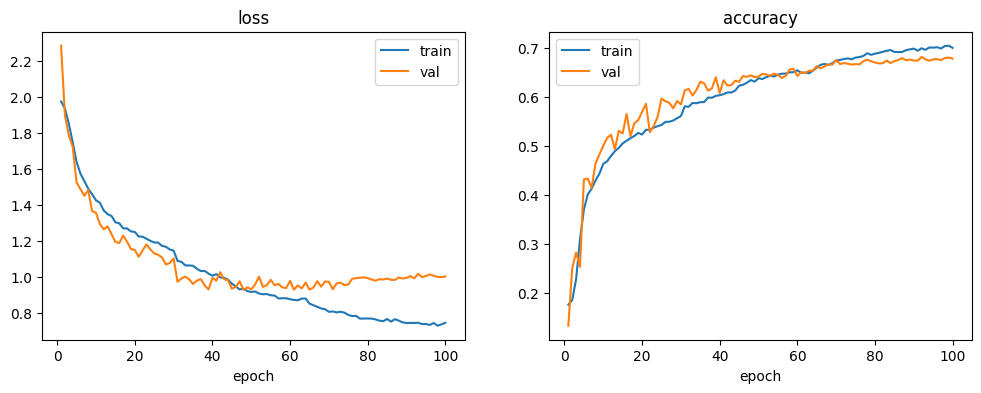

best validation accuracy: 0.6825


In [ ]:
ep = range(1, len(history["train_loss"]) + 1)
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4))
a.plot(ep, history["train_loss"], label="train"); a.plot(ep, history["val_loss"], label="val")
a.set(title="loss", xlabel="epoch"); a.legend()
b.plot(ep, history["train_acc"], label="train"); b.plot(ep, history["val_acc"], label="val")
b.set(title="accuracy", xlabel="epoch"); b.legend()
plt.show()
print(f"best validation accuracy: {best_val:.4f}")

## Test-set evaluation

`EVAL_SPLIT = "val"` while tuning; switch to `"test"` for the final held-out number.

In [ ]:
EVAL_SPLIT = "test"            # "val" while experimenting, "test" for the final number
dl = test_loader if EVAL_SPLIT == "test" else val_loader

_, acc, preds, labels = run_epoch(model, dl, nn.CrossEntropyLoss())
print(f"{EVAL_SPLIT} accuracy: {acc:.4f}")
print()
print(classification_report(labels, preds, target_names=CLASSES, digits=3))

test accuracy: 0.6812

              precision    recall  f1-score   support

       angry      0.597     0.634     0.615       958
     disgust      0.609     0.757     0.675       111
        fear      0.544     0.461     0.499      1024
       happy      0.893     0.859     0.876      1774
     neutral      0.594     0.711     0.647      1233
         sad      0.602     0.502     0.547      1247
    surprise      0.750     0.842     0.794       831

    accuracy                          0.681      7178
   macro avg      0.656     0.681     0.665      7178
weighted avg      0.681     0.681     0.678      7178



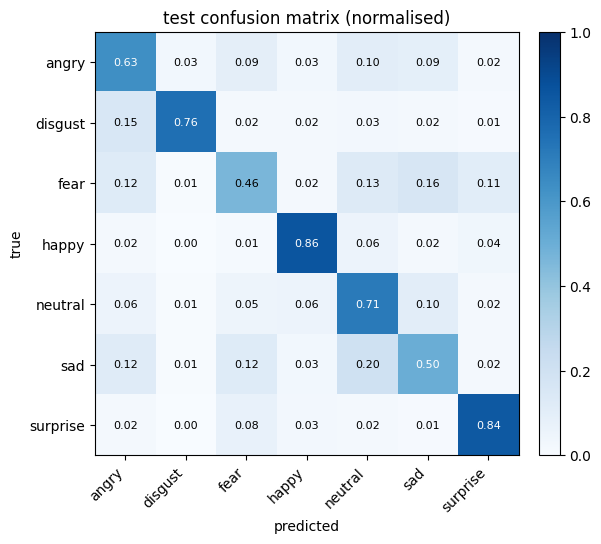

In [ ]:
cm = confusion_matrix(labels, preds).astype(float)
cm /= cm.sum(1, keepdims=True)        # normalise per true class
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(N_CLASSES), CLASSES)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
ax.set(xlabel="predicted", ylabel="true", title=f"{EVAL_SPLIT} confusion matrix (normalised)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

## Where it goes wrong

The matrix says how many; these are the actual faces. A lot of the fear/sad mix-ups are understandable even for a human

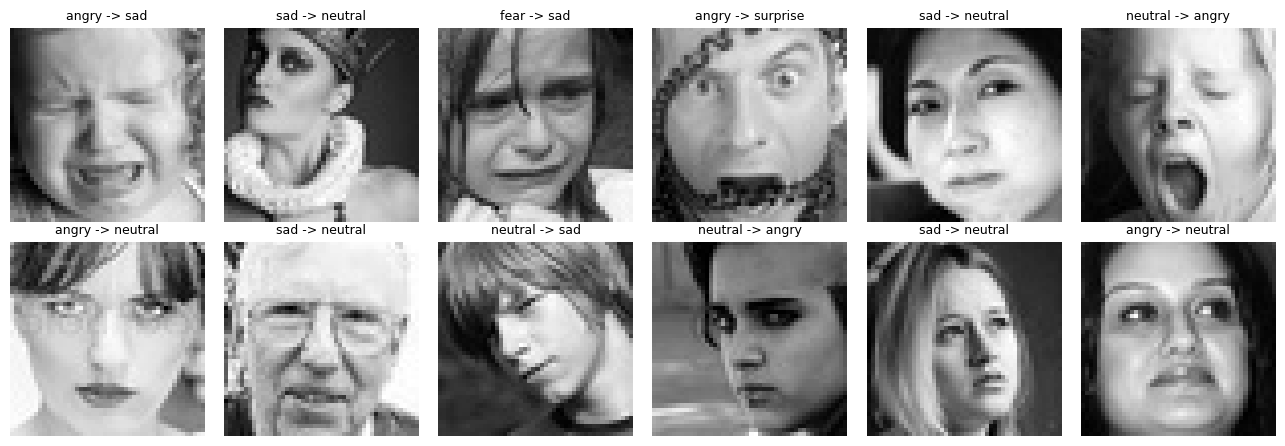

2288 / 7178 misclassified


In [ ]:
# line the predictions back up with their file paths (loaders are shuffle=False here)
if EVAL_SPLIT == "test":
    paths = [p for p, _ in test_set.samples]
else:
    paths = [train_clean.samples[i][0] for i in val_idx]

wrong = [k for k in range(len(labels)) if preds[k] != labels[k]]
random.shuffle(wrong)

fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for ax, k in zip(axes.ravel(), wrong[:12]):
    ax.imshow(Image.open(paths[k]), cmap="gray")
    ax.set_title(f"{CLASSES[labels[k]]} -> {CLASSES[preds[k]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"{len(wrong)} / {len(labels)} misclassified")

In [ ]:
# dump every mistake to disk, grouped by true_as_predicted (same as the script version)
mis_dir = os.path.join(run, f"wrongly_categorized_{EVAL_SPLIT}")
if os.path.isdir(mis_dir):
    shutil.rmtree(mis_dir)
for k in wrong:
    sub = os.path.join(mis_dir, f"{CLASSES[labels[k]]}_as_{CLASSES[preds[k]]}")
    os.makedirs(sub, exist_ok=True)
    shutil.copy(paths[k], sub)
print(f"saved {len(wrong)} images under {mis_dir}")

saved 2288 images under outputs\20260606_160733\wrongly_categorized_test
